In [1]:
import numpy as np
import matplotlib.pyplot as plt



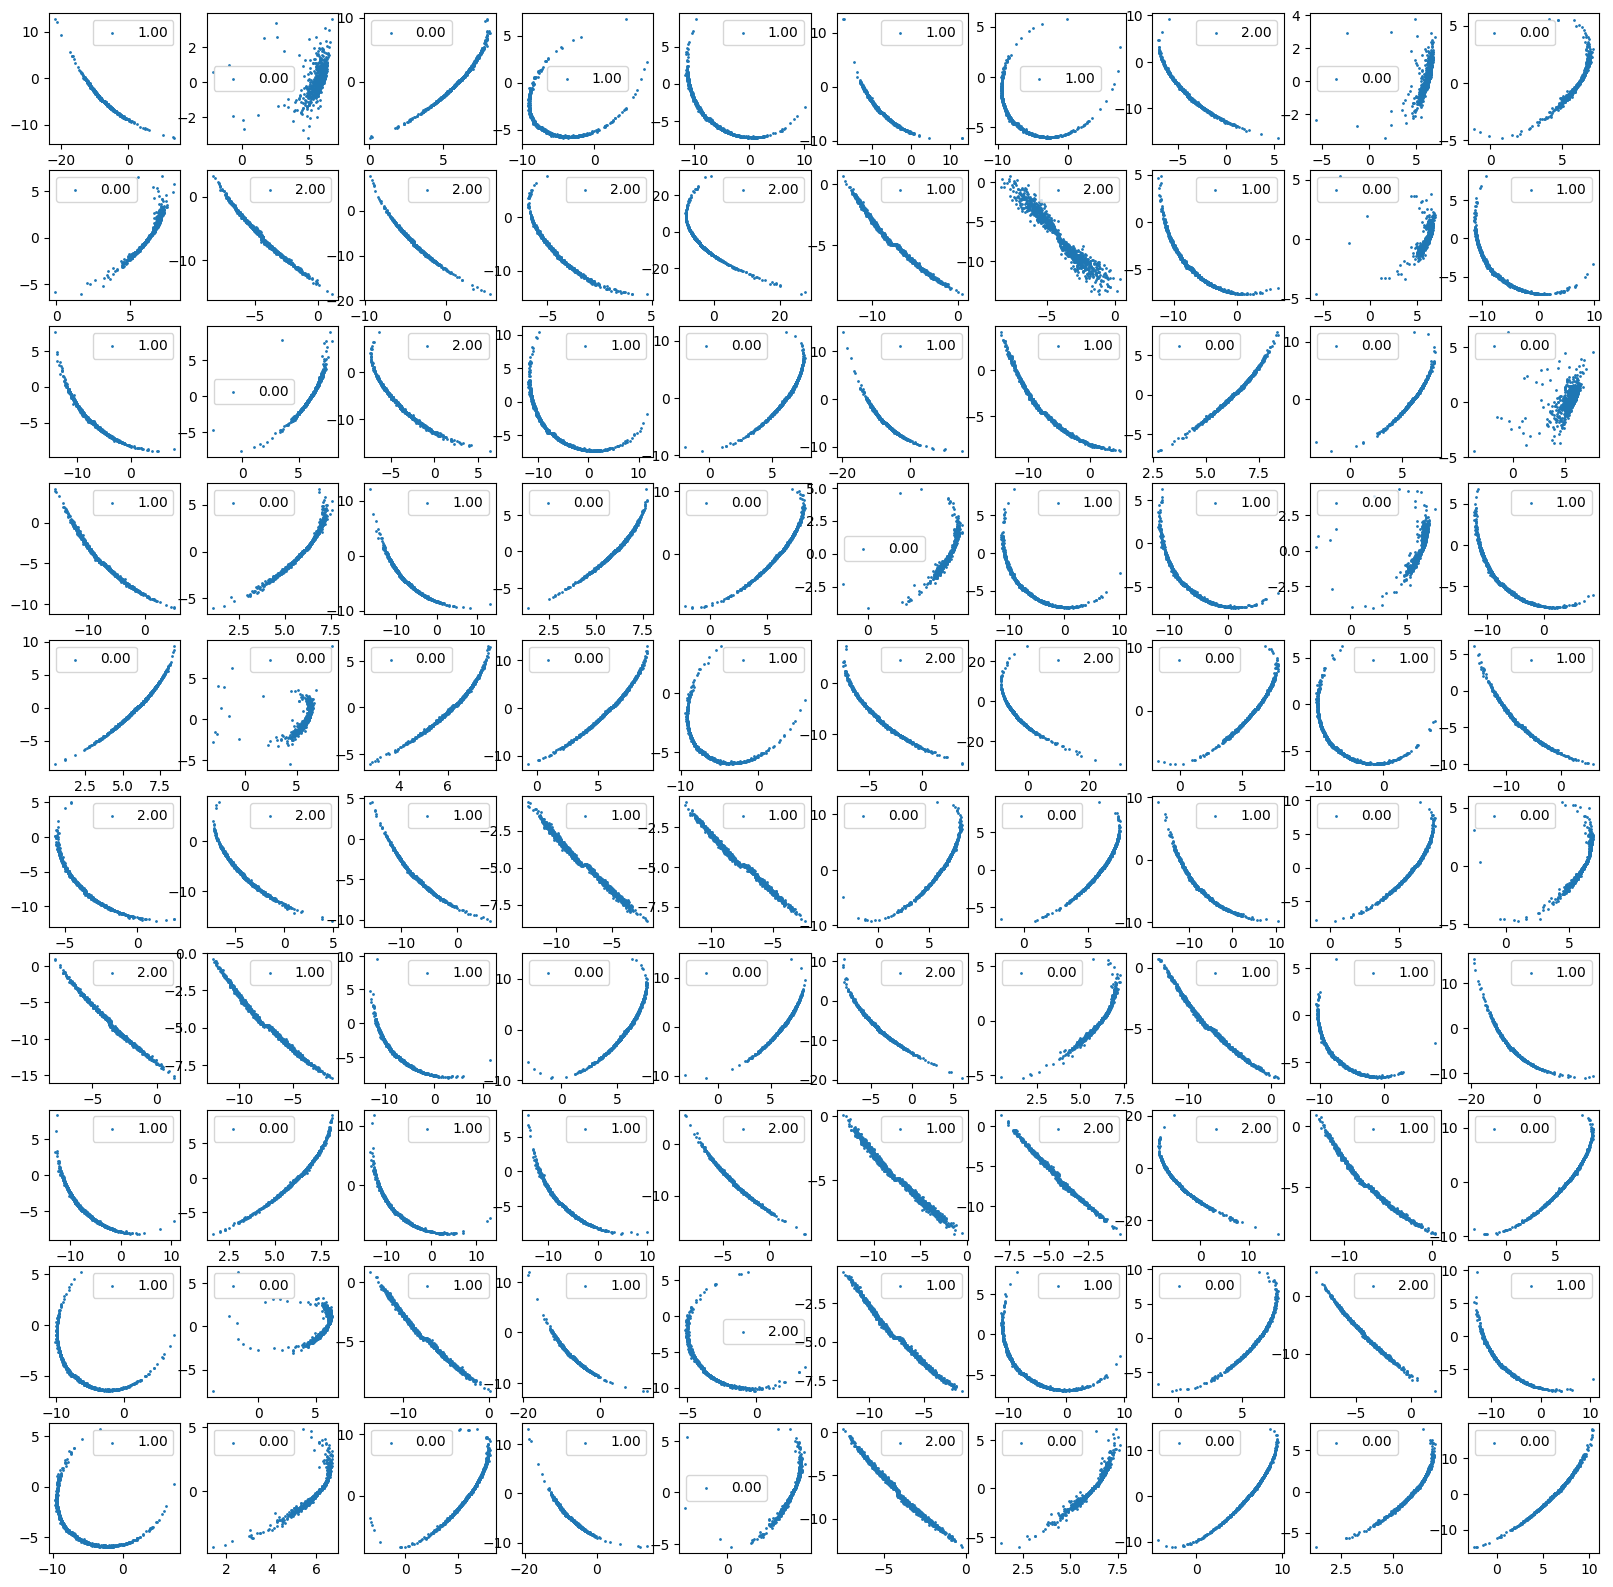

In [3]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(0, 100)):
    data = np.load(f'../data/streams/data_galax/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['j'][0]:.2f}")
    ax.legend()

/tmp/ipykernel_1398230/1668479910.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  j = int(data['j'])


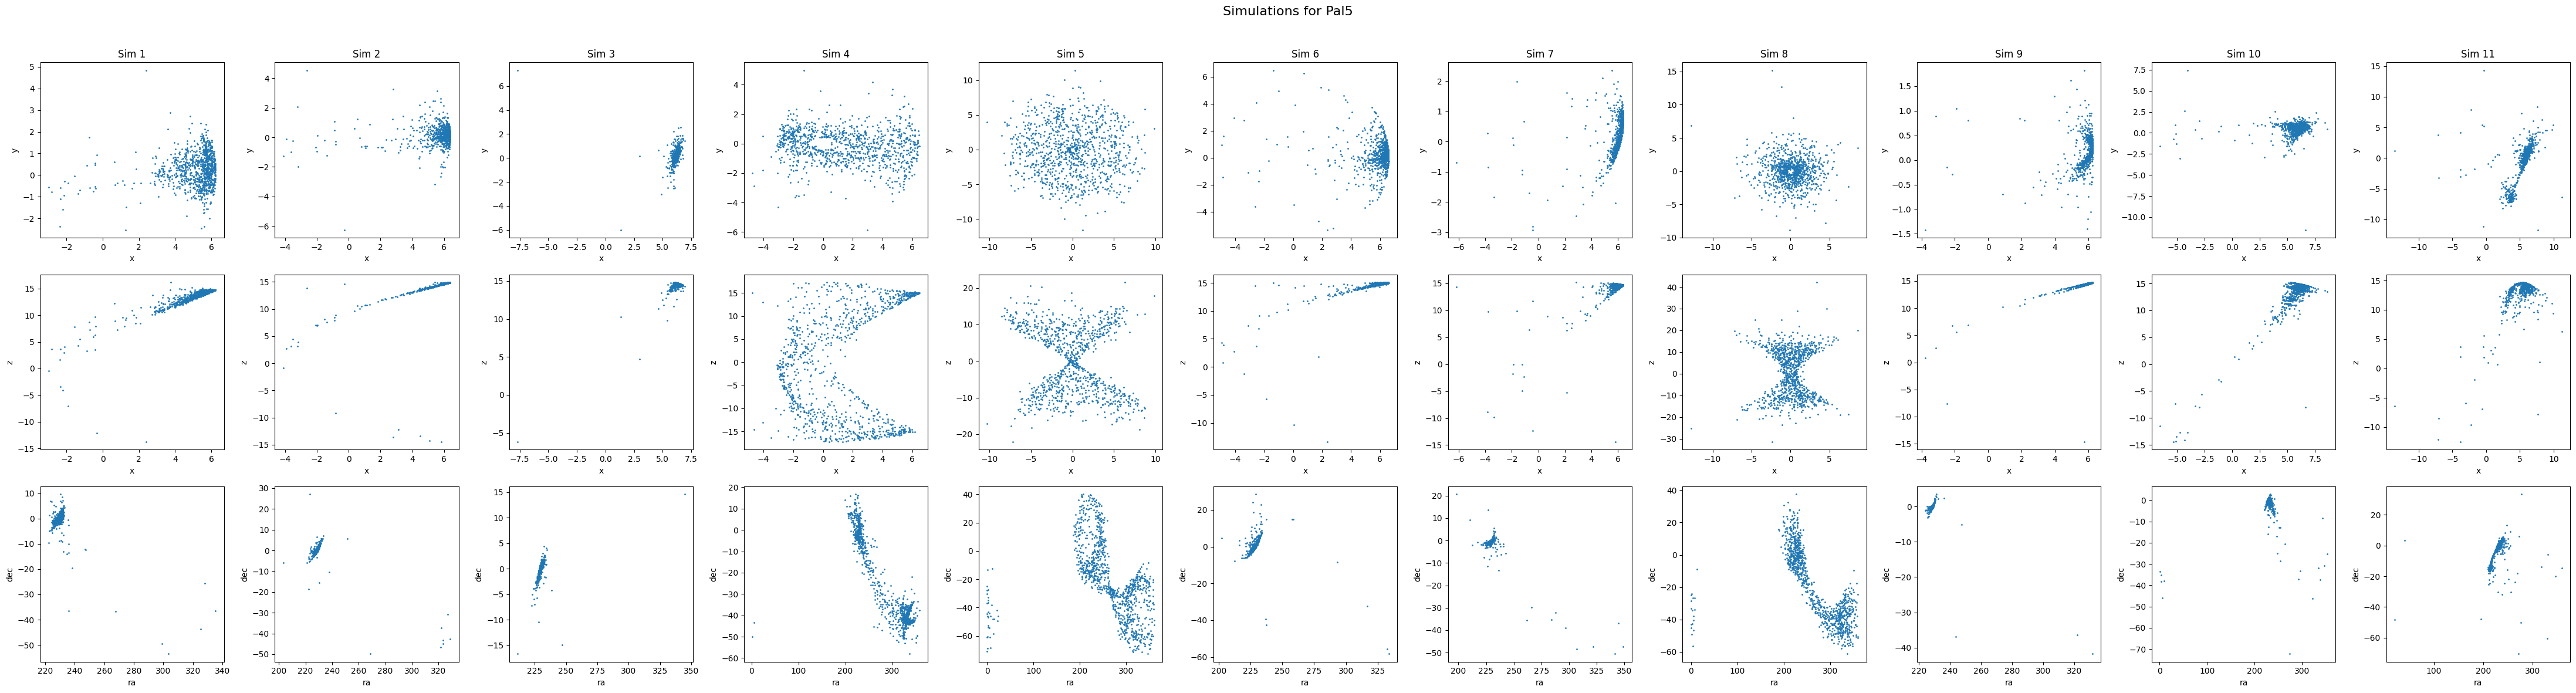

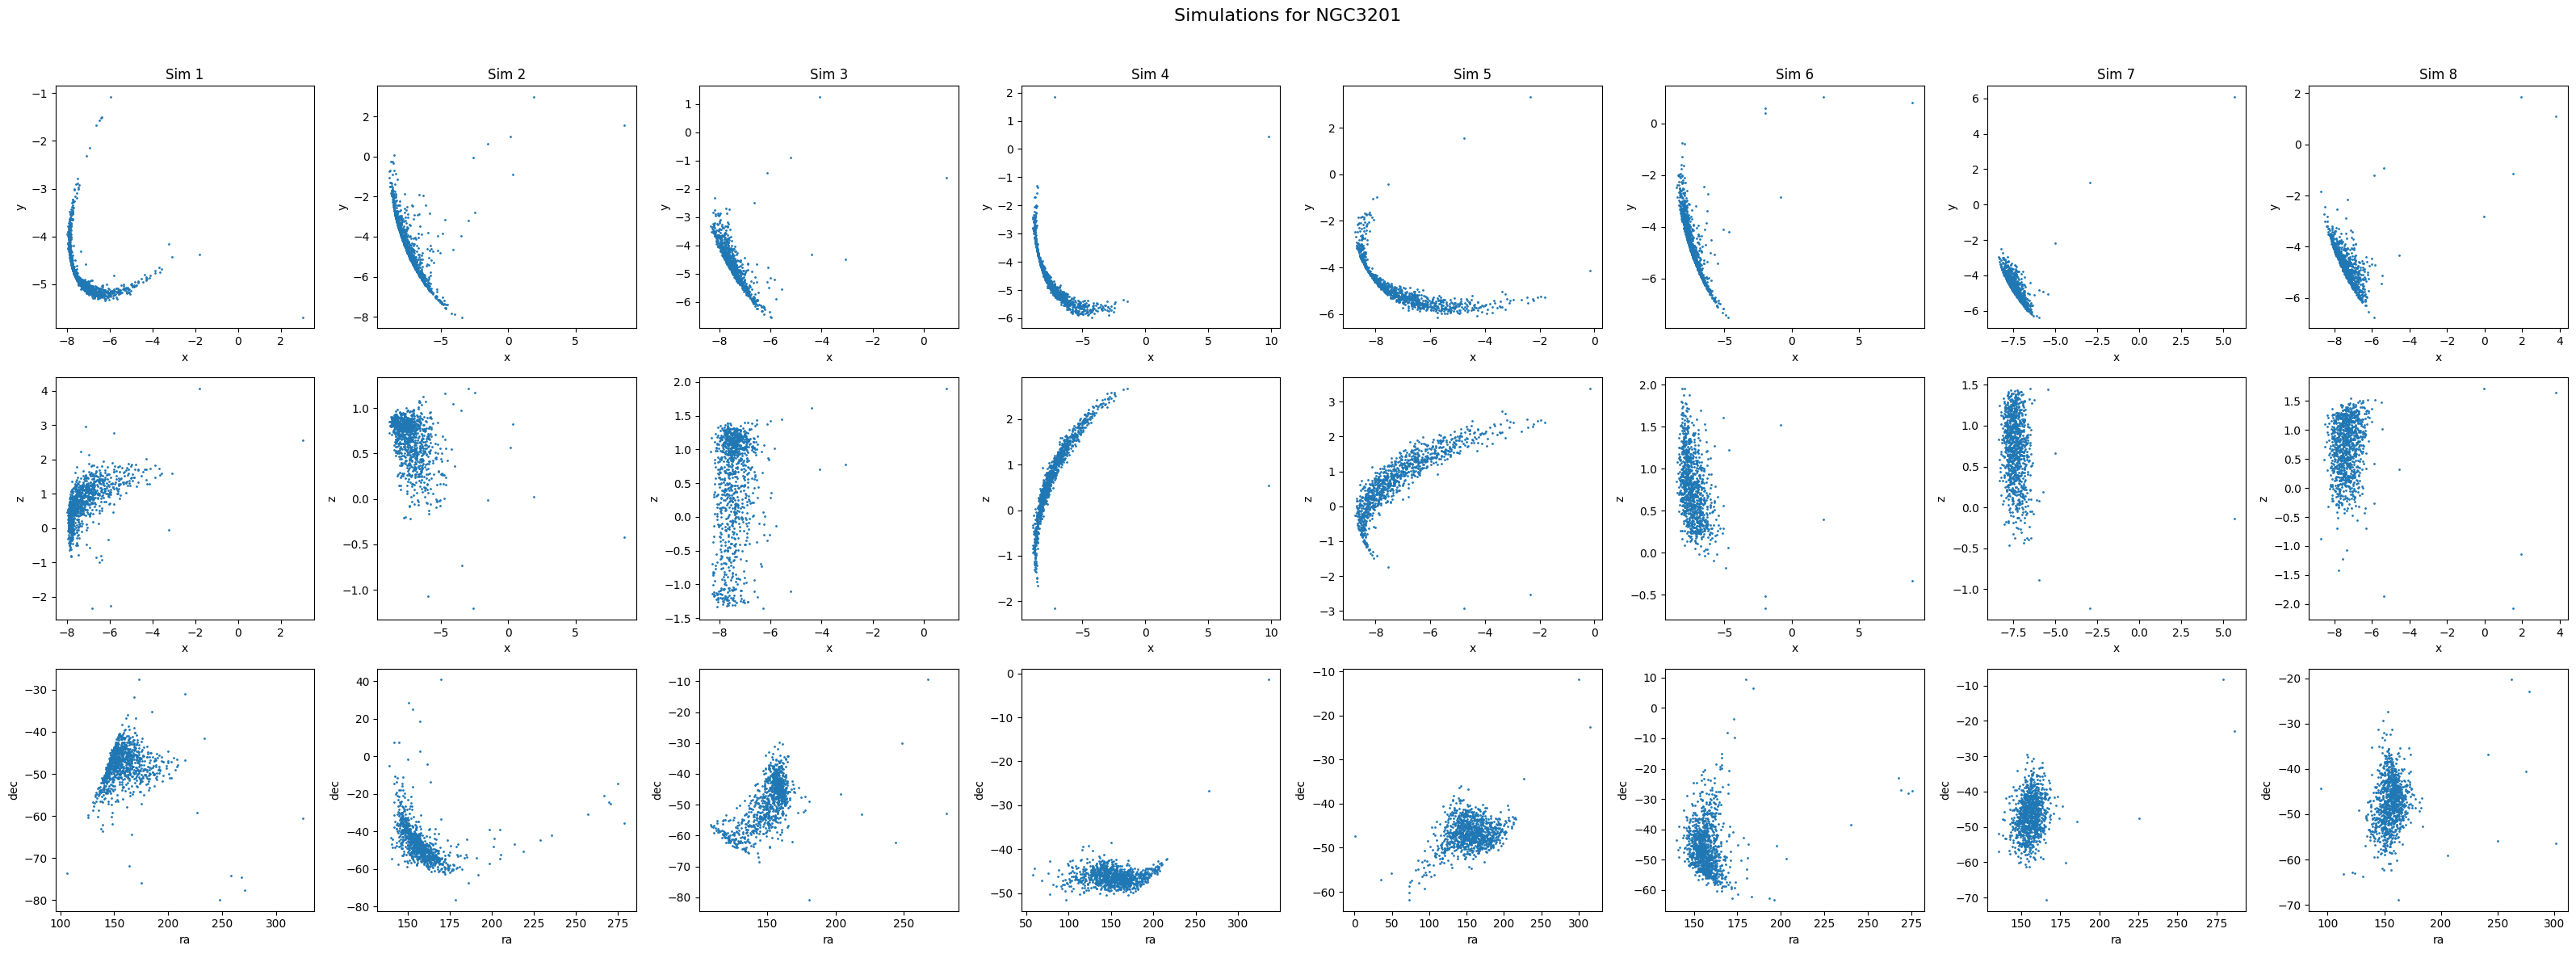

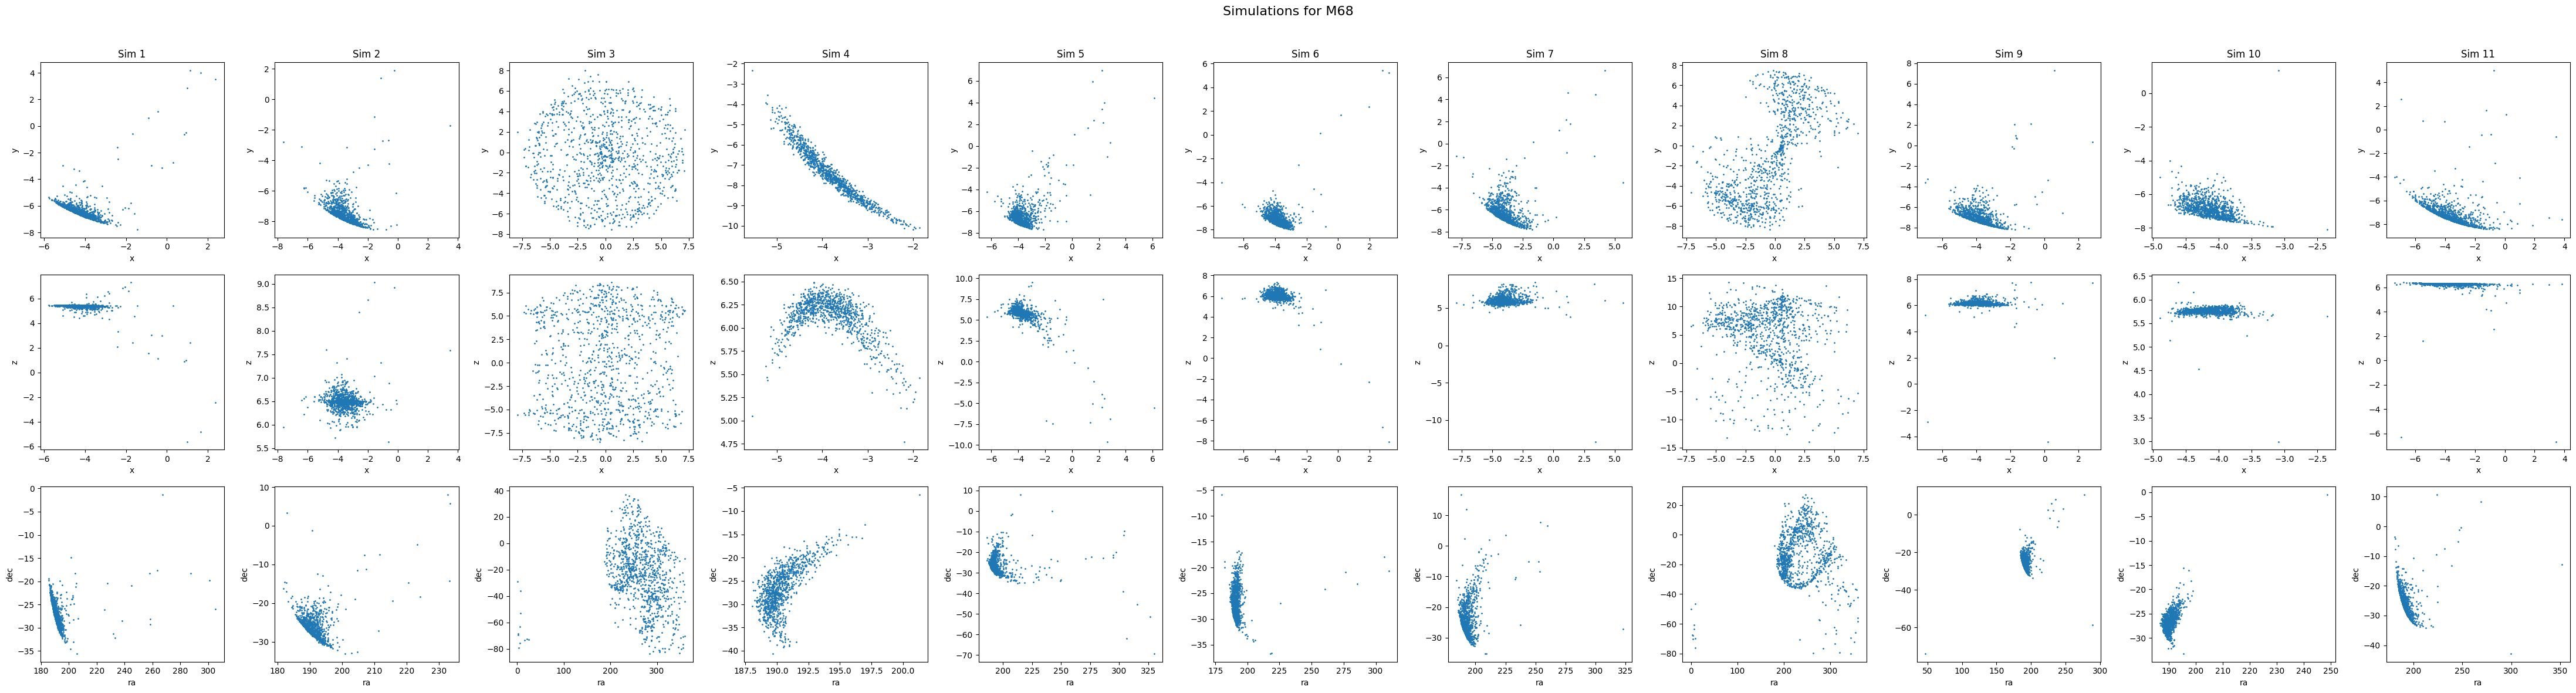

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Map j index to stream name
target_streams = {
    "Pal5": 0,
    "NGC3201": 1,
    "M68": 2
}
# Reverse mapping for convenience
j_to_stream = {v: k for k, v in target_streams.items()}

# 1. Gather all simulation files
sim_files = sorted(glob.glob('./data/streams/data/simulation_*.npz'))

# 2. Construct sim_data: {stream_name: [sim_result, ...]}
sim_data = {name: [] for name in target_streams}
for fname in sim_files:
    data = np.load(fname)
    j = int(data['j'])
    stream_name = j_to_stream.get(j, None)
    if stream_name is None:
        continue
    sim_result = {
        'x': data['sim_data_carthesian'][:, 0],
        'y': data['sim_data_carthesian'][:, 1],
        'z': data['sim_data_carthesian'][:, 2],
        'ra': data['sim_data_projected'][:, 0],
        'dec': data['sim_data_projected'][:, 1]
    }
    sim_data[stream_name].append(sim_result)

# 3. Plotting
for stream_name, sim_list in sim_data.items():
    n_sim = len(sim_list)
    if n_sim == 0:
        continue
    fig, axes = plt.subplots(3, n_sim, figsize=(4*n_sim, 12), squeeze=False)
    fig.suptitle(f"Simulations for {stream_name}", fontsize=16)
    for i, sim in enumerate(sim_list):
        axes[0, i].scatter(sim['x'], sim['y'], s=1)
        axes[0, i].set_xlabel('x')
        axes[0, i].set_ylabel('y')
        axes[0, i].set_title(f'Sim {i+1}')
        axes[1, i].scatter(sim['x'], sim['z'], s=1)
        axes[1, i].set_xlabel('x')
        axes[1, i].set_ylabel('z')
        axes[2, i].scatter(sim['ra'], sim['dec'], s=1)
        axes[2, i].set_xlabel('ra')
        axes[2, i].set_ylabel('dec')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()